## Trying to figure out what's up with the time alignment!

In [4]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [5]:
def flatten_cell(cell):
    # Handle nested lists or arrays
    if isinstance(cell, (list, np.ndarray)):
        return cell[0] if len(cell) > 0 else None  # Extract the first element if not empty
    return cell

In [6]:
df = pd.read_csv("TrialInfoTest.csv")
df = df[df['Date'] == 240506]
df = df[df['Recording'] == 1]

# Movie & Specs
filepath = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/cG_unmixed_dFF.h5"
with h5py.File(filepath, 'r') as mov_file:
    movie = mov_file["mov"][()]
    specs = mov_file["specs"]
    fps = specs["fps"][()][0][0]
    timeorigin = specs["timeorigin"][()][0][0] #*************
    timebinning = specs["timebinning"][()][0][0]
    timestamps_table = specs["extra_specs"]["timestamps_table"][()].squeeze()
    timestamps_table_names = specs["extra_specs"]["timestamps_table_names"][()]
    timestamps_table_names = b''.join(timestamps_table_names.flatten()).decode("utf-8").split(';')

In [13]:
Path = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/Behavioral_Data/cfm001mjr/Volt_240506_processed.mat"
data2 = loadmat(Path)
df2 = pd.DataFrame(data2["MasterN"]).map(flatten_cell).map(flatten_cell).map(flatten_cell)
df2.columns = df2.iloc[0]  
df2 = df2[1:]               # Making sure column names are in correct positions
delayEstimates = df2['FrameAlignmentInfo'][1][0][0]
delay = np.mean(delayEstimates)
df['BFMTime'] = df['Time'] - delay - int(timeorigin)/fps           # Subtracting delay from each trial time to convert to BFM time
df.insert(5, "BFMTime", df.pop("BFMTime"))    # Putting BFMTime column beside Time

/var/folders/0k/yytc9ywn0k3_j19jtm2h_cr00000gn/T/ipykernel_16222/278630794.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  df['BFMTime'] = df['Time'] - delay - int(timeorigin)/fps           # Subtracting delay from each trial time to convert to BFM time


In [14]:
## Generating ttl trace from df and movie

def generate_ttl_trace(df, fps, total_frames):
    """
    Generates a TTL trace (1 for stimulus on, 0 for stimulus off) for each frame in the movie.

    Args:
    - df (pd.DataFrame): DataFrame containing 'BFMTime', 'Duration', and 'Date'.
    - fps (float): Frames per second of the movie.
    - total_frames (int): Total number of frames in the movie.

    Returns:
    - np.ndarray: TTL trace with 1 (stimulus on) and 0 (stimulus off), one value per frame.
    """
    # Initialize the TTL trace with zeros (one entry per frame)
    ttl_trace = np.zeros(total_frames, dtype=int)

    # Loop through each trial in the filtered dataframe
    for _, trial in df.iterrows():
        # Compute the start and end frame indices for this trial
        start_frame = int(trial["BFMTime"] * fps)  # Convert BFMTime to frame index
        end_frame = int((trial["BFMTime"] + trial["Duration"]) * fps)  # Duration in frames

        # Ensure indices are within the bounds of the movie frames
        if start_frame < 0:
            continue  # Skip invalid trials
        if end_frame > total_frames:
            end_frame = total_frames  # Cap at the last frame

        # Set the frames for this trial to 1 (stimulus on)
        ttl_trace[start_frame:end_frame] = 1

    return ttl_trace


def get_ttl_trace(timestamps_table, timestamps_table_names, timeorigin, timebinning=1):
    """
    Extracts the TTL trace from the movie specs.

    Args:
    - timestamps_table (np.ndarray): Timestamps table containing TTL data.
    - timestamps_table_names (np.ndarray): Column names for the timestamps table.
    - timeorigin (int): Starting index for the TTL signal.
    - timebinning (int, optional): Time binning factor for downsampling (default: 1).

    Returns:
    - np.ndarray: Extracted TTL signal.
    """
  
    # Get the column index for 'behavior_ttl'
    ttl_column = timestamps_table_names.index("behavior_ttl")

    # Extract the raw TTL signal starting from `timeorigin`
    ttl_signal_raw = timestamps_table[ttl_column, int(timeorigin):]

    # Apply binning if `timebinning` is greater than 1
    if timebinning > 1:
        # Ensure the length of ttl_signal_raw is divisible by timebinning
        trimmed_length = len(ttl_signal_raw) - (len(ttl_signal_raw) % timebinning)
        ttl_signal_raw = ttl_signal_raw[:trimmed_length]
        
        # Reshape, average over bins, and round the result
        ttl_signal = np.round(np.mean(ttl_signal_raw.reshape(-1, timebinning), axis=1))
    else:
        ttl_signal = ttl_signal_raw

    return ttl_signal


/var/folders/0k/yytc9ywn0k3_j19jtm2h_cr00000gn/T/ipykernel_16222/943690572.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ttl_signal_raw = timestamps_table[ttl_column, int(timeorigin):]
/var/folders/0k/yytc9ywn0k3_j19jtm2h_cr00000gn/T/ipykernel_16222/943690572.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start_frame = int(trial["BFMTime"] * fps)  # Convert BFMTime to frame index
/var/folders/0k/yytc9ywn0k3_j19jtm2h_cr00000gn/T/ipykernel_16222/943690572.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before

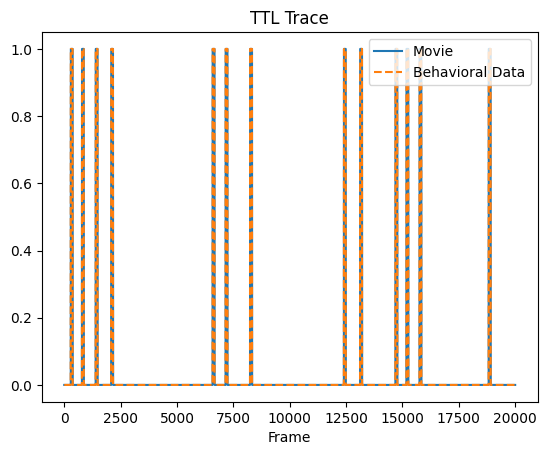

Text(0.5, 1.0, 'TTL Trace')

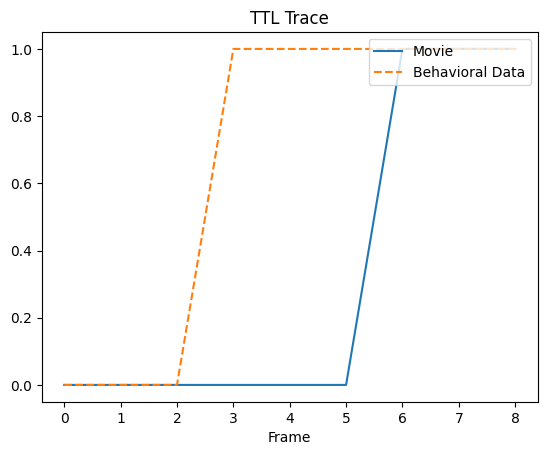

In [20]:
ttl_trace_movie = get_ttl_trace(timestamps_table, timestamps_table_names, timeorigin)
ttl_trace_df = generate_ttl_trace(df, fps, len(movie))

plt.plot(ttl_trace_movie[0:20000])
plt.plot(ttl_trace_df[0:20000], ls='--')
plt.legend(["Movie", "Behavioral Data"], loc=1)
plt.xlabel("Frame")
plt.title("TTL Trace")
plt.show()

plt.plot(ttl_trace_movie[283:292])
plt.plot(ttl_trace_df[283:292], ls='--')
plt.legend(["Movie", "Behavioral Data"], loc=1)
plt.xlabel("Frame")
plt.title("TTL Trace")